# Object-Finder — Classification Binaire Escaliers
## Rôle 2 : Notebook Final — ConvNeXt-Tiny Fine-Tuning

---

> **Projet** : Pipeline YOLO + CNN pour l'aide à la navigation des personnes malvoyantes
> **Auteur** : Mohamed Khalil Khelifi — 4ème année Data Science & IA, École Polytechnique de Sousse
> **Dataset** : Open Images V7 — Stairs (9 541 crops : 7 632 train / 1 909 val)
> **Version** : v2 — Notebook Final

---

##  Contexte & Décisions

### Leçons tirées de v1 (brouillon)

| Observation v1 | Décision v2 |
|---|---|
| Double correction (Sampler + Loss) → redondante sur 60/40 | **Loss pondérée seule** |
| CosineAnnealingLR → conservateur | **OneCycleLR** → warmup + peak + descente |
| Dropout 0.3 | **Dropout 0.4** → légèrement plus de régularisation |
| Threshold 0.5 par défaut | **Threshold optimal** depuis courbe ROC v1 |
| F1 v1 = 0.965 | Objectif v2 : maintenir ou dépasser |

### Pipeline complet
```
Image caméra
      │
 YOLOv8 → bounding box "stairs"  (YOLO ne détecte pas les escaliers — absent COCO)
      │
 Crop 224×224
      │
 ConvNeXt-Tiny Fine-Tuné (v2)
      │
 stairs / pas_stairs  →   ALERTE VOCALE
```

---

## 0 — Imports & Configuration

In [1]:
import os, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    EarlyStopping, ModelCheckpoint
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_curve, auc,
    precision_score, recall_score
)

warnings.filterwarnings('ignore')

# ── Reproductibilité ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ───────────────────────────────────────────────────
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Constantes ────────────────────────────────────────────────
NUM_CLASSES  = 2
CLASS_NAMES  = ["pas_stairs", "stairs"]
CLASS_TO_IDX = {"pas_stairs": 0, "stairs": 1}
IDX_TO_CLASS = {0: "pas_stairs", 1: "stairs"}

print(f"PyTorch   : {torch.__version__}")
print(f"Lightning : {pl.__version__}")
print(f"Device    : {device}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch   : 2.10.0+cu128
Lightning : 2.6.1
Device    : cuda
GPU       : Tesla T4
VRAM      : 15.6 GB


## 1 — Chargement des Données

In [2]:
BASE   = "/kaggle/input/notebooks/mohamedkhalilkh/1-eda-preprocessing-stairs"
df_all = pd.read_csv(f"{BASE}/stairs_dataset.csv")

def fix_chemin(row):
    fname = os.path.basename(row["chemin"])
    return os.path.join(BASE, "crops", row["classe"], fname)

df_all["chemin"] = df_all.apply(fix_chemin, axis=1)
train_df = df_all[df_all["split"] == "train"].reset_index(drop=True)
val_df   = df_all[df_all["split"] == "val"].reset_index(drop=True)

print("=" * 55)
print("   Distribution du Dataset — Stairs")
print("=" * 55)
for split, df in [("Train", train_df), ("Val", val_df)]:
    print(f"\n  {split} ({len(df)} images) :")
    for cls, n in df["classe"].value_counts().items():
        pct = n / len(df) * 100
        bar = "█" * int(pct / 2)
        print(f"    {cls:<15} : {n:>5}  ({pct:.1f}%)  {bar}")

n_exist = train_df["chemin"].apply(os.path.exists).sum()
print(f"\n  Images train trouvées : {n_exist}/{len(train_df)}")
print(f"   OK" if n_exist == len(train_df) else f"    Manquantes : {len(train_df)-n_exist}")

   Distribution du Dataset — Stairs

  Train (7632 images) :
    stairs          :  4546  (59.6%)  █████████████████████████████
    pas_stairs      :  3086  (40.4%)  ████████████████████

  Val (1909 images) :
    stairs          :  1141  (59.8%)  █████████████████████████████
    pas_stairs      :   768  (40.2%)  ████████████████████

  Images train trouvées : 7632/7632
   OK


## 2 — Dataset, Augmentation & DataLoaders

### Correction du déséquilibre — v2 : Loss pondérée seule

```
v1 : WeightedRandomSampler + Loss pondérée  → double correction (redondante sur 60/40)
v2 : Loss pondérée seule + shuffle=True     → correction unique, gradient plus stable
```

**Pourquoi Loss pondérée seule suffit ici ?**
Le déséquilibre est modéré (60% / 40%). Le Sampler sur-représente `pas_stairs` dans chaque batch
ET la Loss le pénalise encore → double signal → gradient instable inutilement.
Avec Loss seule, le modèle voit la vraie distribution mais paie plus cher ses erreurs
sur `pas_stairs` → correction plus douce et plus stable.

In [3]:
# ── Classe Dataset ───────────────────────────────────────────
class StairsDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["chemin"]).convert("RGB")
        label = CLASS_TO_IDX[row["classe"]]
        if self.transform:
            image = self.transform(image)
        return image, label

# ── Transforms ────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.08),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ── v2 : Loss pondérée seule ──────────────────────────────────
labels_train = [CLASS_TO_IDX[c] for c in train_df["classe"]]
class_counts = Counter(labels_train)

loss_w = torch.tensor(
    [1.0 / math.sqrt(class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
)
loss_w = loss_w / loss_w.sum() * NUM_CLASSES
loss_weights = loss_w.to(device)

print(" v2 — Correction unique : Loss pondérée seule")
print(f"  pas_stairs weight : {loss_weights[0]:.4f}")
print(f"  stairs weight     : {loss_weights[1]:.4f}")
print(f"  shuffle=True      : distribution naturelle dans les batches")

# ── DataLoaders ───────────────────────────────────────────────
BATCH_SIZE = 32

train_loader = DataLoader(
    StairsDataset(train_df, train_transform),
    batch_size  = BATCH_SIZE,
    shuffle     = True,        # ← pas de Sampler → shuffle standard
    num_workers = 2,
    pin_memory  = True
)
val_loader = DataLoader(
    StairsDataset(val_df, val_transform),
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"\nDataLoaders prêts :")
print(f"  Batches train : {len(train_loader)}")
print(f"  Batches val   : {len(val_loader)}")

 v2 — Correction unique : Loss pondérée seule
  pas_stairs weight : 1.0965
  stairs weight     : 0.9035
  shuffle=True      : distribution naturelle dans les batches

DataLoaders prêts :
  Batches train : 239
  Batches val   : 60


## 3 — Architecture — ConvNeXt-Tiny Fine-Tuning

### Stratégie fine-tuning complète
```
Phase unique : toutes les couches dégelées
  backbone features  → lr = 1e-5  (très lent — préserver poids ImageNet)
  classifier head    → lr = 1e-4  (plus rapide — apprendre nos 2 classes)

Scheduler : OneCycleLR
  warmup (30%) → peak lr → descente cosinus → eta_min
  → meilleure convergence que CosineAnnealingLR (v1)
```

### Différences clés v1 → v2

| Composant | v1 | v2 |
|---|---|---|
| Correction | Sampler + Loss | **Loss seule** |
| Scheduler | CosineAnnealingLR | **OneCycleLR** |
| Dropout | 0.3 | **0.4** |
| label_smoothing | 0.1 | **0.05** |

In [4]:
class ConvNeXtFineTunedV2(pl.LightningModule):
    """
    ConvNeXt-Tiny Fine-Tuning — Version Finale (v2).

    Améliorations vs v1 :
      - Correction unique : Loss pondérée seule (pas de Sampler)
      - OneCycleLR : warmup + peak + descente cosinus
      - Dropout 0.4 (vs 0.3 en v1)
      - label_smoothing 0.05 (vs 0.1 en v1)
    """

    def __init__(
        self,
        lr_backbone    : float = 1e-5,
        lr_head        : float = 1e-4,
        loss_weights   = None,
        label_smoothing: float = 0.05,
        dropout        : float = 0.4,
        steps_per_epoch: int   = 1,
        max_epochs     : int   = 15,
    ):
        super().__init__()
        self.save_hyperparameters(ignore=['loss_weights'])
        self.lr_backbone      = lr_backbone
        self.lr_head          = lr_head
        self.steps_per_epoch  = steps_per_epoch
        self.max_epochs       = max_epochs

        # ── Backbone ConvNeXt-Tiny — toutes couches dégelées ─────────────────
        backbone = models.convnext_tiny(weights='IMAGENET1K_V1')
        for param in backbone.parameters():
            param.requires_grad = True

        # ── Tête personnalisée ────────────────────────────────────────────────
        backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(dropout),
            nn.Linear(768, NUM_CLASSES)
        )
        self.model = backbone

        # ── Loss pondérée seule (v2) ──────────────────────────────────────────
        self.criterion = nn.CrossEntropyLoss(
            weight          = loss_weights,
            label_smoothing = label_smoothing
        )

        # ── Métriques ─────────────────────────────────────────────────────────
        self.train_acc_m = torchmetrics.Accuracy(task='binary')
        self.val_acc_m   = torchmetrics.Accuracy(task='binary')
        self.val_f1_m    = torchmetrics.F1Score(task='binary', average='macro')

        # ── Historique automatique ────────────────────────────────────────────
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc' : [], 'val_acc' : [],
            'val_f1'    : [], 'lr'      : []
        }

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs)
        loss   = self.criterion(logits, labels)
        preds  = logits.argmax(dim=1)
        self.train_acc_m(preds, labels)
        self.log('train_loss', loss,             on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc',  self.train_acc_m, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs)
        loss   = self.criterion(logits, labels)
        preds  = logits.argmax(dim=1)
        self.val_acc_m(preds, labels)
        self.val_f1_m(preds, labels)
        self.log('val_loss', loss,             prog_bar=True)
        self.log('val_acc',  self.val_acc_m,   prog_bar=True)
        self.log('val_f1',   self.val_f1_m,    prog_bar=True)

    def on_train_epoch_end(self):
        logs = self.trainer.callback_metrics
        self.history['train_loss'].append(float(logs.get('train_loss', 0)))
        self.history['train_acc' ].append(float(logs.get('train_acc',  0)))
        # LR courant
        opt = self.optimizers()
        self.history['lr'].append(opt.param_groups[-1]['lr'])

    def on_validation_epoch_end(self):
        logs = self.trainer.callback_metrics
        self.history['val_loss'].append(float(logs.get('val_loss', 0)))
        self.history['val_acc' ].append(float(logs.get('val_acc',  0)))
        self.history['val_f1'  ].append(float(logs.get('val_f1',   0)))

    def configure_optimizers(self):
        # ── Dual learning rates ───────────────────────────────────────────────
        backbone_params = [p for n, p in self.model.named_parameters()
                           if 'classifier' not in n]
        head_params     = [p for n, p in self.model.named_parameters()
                           if 'classifier' in n]

        optimizer = torch.optim.AdamW([
            {'params': backbone_params, 'lr': self.lr_backbone},
            {'params': head_params,     'lr': self.lr_head    },
        ], weight_decay=1e-4)

        # ── OneCycleLR : warmup → peak → descente ────────────────────────────
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr          = [self.lr_backbone * 10, self.lr_head * 10],
            steps_per_epoch = self.steps_per_epoch,
            epochs          = self.max_epochs,
            pct_start       = 0.3,      # 30% warmup
            div_factor      = 10,       # lr_start = max_lr / 10
            final_div_factor= 1000,     # lr_end   = max_lr / 1000
            anneal_strategy = 'cos'
        )
        return {
            'optimizer'   : optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval' : 'step',   # OneCycleLR se met à jour à chaque step
                'frequency': 1
            }
        }

# ── Stats ─────────────────────────────────────────────────────
_tmp    = ConvNeXtFineTunedV2(steps_per_epoch=len(train_loader))
tot_p   = sum(p.numel() for p in _tmp.parameters())
train_p = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
del _tmp

print("ConvNeXt-Tiny Fine-Tuning v2 — Version Finale")
print(f"  Paramètres totaux       : {tot_p:,}")
print(f"  Paramètres entraînables : {train_p:,}  (100% — toutes couches dégelées)")
print(f"  lr backbone             : 1e-5  →  peak 1e-4  (OneCycleLR)")
print(f"  lr head                 : 1e-4  →  peak 1e-3  (OneCycleLR)")
print(f"  Scheduler               : OneCycleLR (warmup 30%)")
print(f"  Correction déséquilibre : Loss pondérée seule (v2)")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 238MB/s] 


ConvNeXt-Tiny Fine-Tuning v2 — Version Finale
  Paramètres totaux       : 27,821,666
  Paramètres entraînables : 27,821,666  (100% — toutes couches dégelées)
  lr backbone             : 1e-5  →  peak 1e-4  (OneCycleLR)
  lr head                 : 1e-4  →  peak 1e-3  (OneCycleLR)
  Scheduler               : OneCycleLR (warmup 30%)
  Correction déséquilibre : Loss pondérée seule (v2)


## 4 — Entraînement

In [5]:
# ── Callbacks ─────────────────────────────────────────────────
class EpochLogger(pl.Callback):
    """Print à chaque epoch — évite le timeout Kaggle."""
    def on_validation_epoch_end(self, trainer, pl_module):
        logs = trainer.callback_metrics
        ep   = trainer.current_epoch + 1
        print(
            f"  Epoch {ep:02d} | "
            f"train_loss={logs.get('train_loss',0):.4f} | "
            f"val_loss={logs.get('val_loss',0):.4f} | "
            f"val_acc={logs.get('val_acc',0)*100:.2f}% | "
            f"val_f1={logs.get('val_f1',0)*100:.2f}%"
        )

EPOCHS_FT = 15

early_stop = EarlyStopping(
    monitor  = 'val_f1',
    patience = 5,
    mode     = 'max'
)
checkpoint = ModelCheckpoint(
    monitor   = 'val_f1',
    mode      = 'max',
    save_top_k= 1,
    filename  = 'convnext_stairs_v2_best',
    dirpath   = '/kaggle/working/'
)

# ── Instanciation ──────────────────────────────────────────────
model_ft = ConvNeXtFineTunedV2(
    lr_backbone     = 1e-5,
    lr_head         = 1e-4,
    loss_weights    = loss_weights,
    label_smoothing = 0.05,
    dropout         = 0.4,
    steps_per_epoch = len(train_loader),
    max_epochs      = EPOCHS_FT
)

trainer = pl.Trainer(
    max_epochs          = EPOCHS_FT,
    accelerator         = accelerator,
    callbacks           = [early_stop, checkpoint, EpochLogger()],
    enable_progress_bar = False,
    logger              = False,
    gradient_clip_val   = 1.0,
)

print(f"Lancement fine-tuning v2 — max {EPOCHS_FT} epochs")
print(f"Scheduler  : OneCycleLR (warmup 30%)")
print(f"Correction : Loss pondérée seule")
print("-" * 60)

t0 = time.time()
trainer.fit(model_ft, train_loader, val_loader)
elapsed = time.time() - t0

print("-" * 60)
print(f" Fine-tuning terminé en {elapsed/60:.1f} min")
print(f"   Epochs réels    : {trainer.current_epoch}")
print(f"   Meilleur modèle : {checkpoint.best_model_path}")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Lancement fine-tuning v2 — max 15 epochs
Scheduler  : OneCycleLR (warmup 30%)
Correction : Loss pondérée seule
------------------------------------------------------------


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model       │ ConvNeXt         │ 27.8 M │ train │     0 │
│ 1 │ criterion   │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_acc_m │ BinaryAccuracy   │      0 │ train │     0 │
│ 3 │ val_acc_m   │ BinaryAccuracy   │      0 │ train │     0 │
│ 4 │ val_f1_m    │ BinaryF1Score    │      0 │ train │     0 │
└───┴─────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 27.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 27.8 M                                                                                               
Total estimated model params size (MB): 111                                                                        
Modules in train mode: 209                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

  Epoch 01 | train_loss=0.0000 | val_loss=0.8237 | val_acc=40.62% | val_f1=57.78%
  Epoch 01 | train_loss=0.0000 | val_loss=0.2422 | val_acc=93.77% | val_f1=94.75%
  Epoch 02 | train_loss=0.4149 | val_loss=0.2323 | val_acc=93.77% | val_f1=94.64%
  Epoch 03 | train_loss=0.2774 | val_loss=0.2099 | val_acc=95.23% | val_f1=96.05%
  Epoch 04 | train_loss=0.2495 | val_loss=0.2068 | val_acc=95.18% | val_f1=95.95%
  Epoch 05 | train_loss=0.2341 | val_loss=0.2065 | val_acc=95.91% | val_f1=96.54%
  Epoch 06 | train_loss=0.2232 | val_loss=0.2362 | val_acc=95.34% | val_f1=96.06%
  Epoch 07 | train_loss=0.2033 | val_loss=0.2149 | val_acc=96.23% | val_f1=96.88%
  Epoch 08 | train_loss=0.1905 | val_loss=0.2355 | val_acc=95.55% | val_f1=96.36%
  Epoch 09 | train_loss=0.1727 | val_loss=0.2070 | val_acc=96.54% | val_f1=97.13%
  Epoch 10 | train_loss=0.1649 | val_loss=0.2192 | val_acc=96.07% | val_f1=96.76%
  Epoch 11 | train_loss=0.1564 | val_loss=0.2008 | val_acc=96.54% | val_f1=97.14%
  Epoch 12 | tra

`Trainer.fit` stopped: `max_epochs=15` reached.


------------------------------------------------------------
 Fine-tuning terminé en 37.4 min
   Epochs réels    : 15
   Meilleur modèle : /kaggle/working/convnext_stairs_v2_best.ckpt


## 5 — Courbes d'Apprentissage

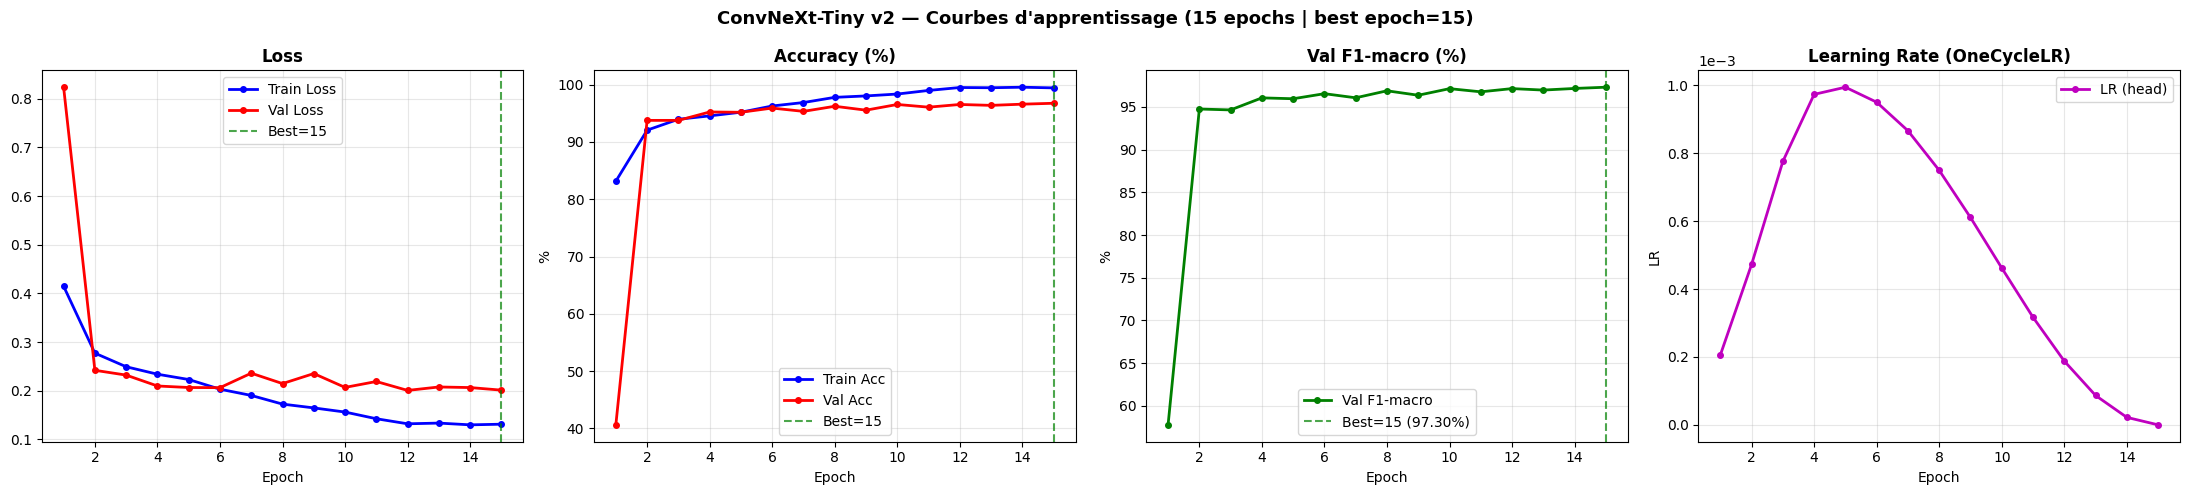

Meilleur epoch  : 15
Meilleur Val F1 : 97.30%
Val Acc au best : 96.75%


In [6]:
# ── Courbes d'apprentissage ────────────────────────────────────
history  = model_ft.history
n_epochs = min(len(history['train_loss']), len(history['val_loss']), len(history['val_f1']))
epochs   = range(1, n_epochs + 1)

train_loss = history['train_loss'][:n_epochs]
val_loss   = history['val_loss']  [:n_epochs]
train_acc  = history['train_acc'] [:n_epochs]
val_acc    = history['val_acc']   [:n_epochs]
val_f1     = history['val_f1']    [:n_epochs]
lr_hist    = history['lr']        [:n_epochs]

best_epoch = val_f1.index(max(val_f1)) + 1

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    f"ConvNeXt-Tiny v2 — Courbes d'apprentissage ({n_epochs} epochs | best epoch={best_epoch})",
    fontsize=13, fontweight='bold'
)

# ── Loss ──────────────────────────────────────────────────────
axes[0].plot(epochs, train_loss, 'b-o', ms=4, lw=2, label='Train Loss')
axes[0].plot(epochs, val_loss,   'r-o', ms=4, lw=2, label='Val Loss')
axes[0].axvline(x=best_epoch, color='green', ls='--', alpha=0.7, label=f'Best={best_epoch}')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────
axes[1].plot(epochs, [a*100 for a in train_acc], 'b-o', ms=4, lw=2, label='Train Acc')
axes[1].plot(epochs, [a*100 for a in val_acc],   'r-o', ms=4, lw=2, label='Val Acc')
axes[1].axvline(x=best_epoch, color='green', ls='--', alpha=0.7, label=f'Best={best_epoch}')
axes[1].set_title('Accuracy (%)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── F1 ────────────────────────────────────────────────────────
axes[2].plot(epochs, [f*100 for f in val_f1], 'g-o', ms=4, lw=2, label='Val F1-macro')
axes[2].axvline(x=best_epoch, color='green', ls='--', alpha=0.7,
                label=f'Best={best_epoch} ({max(val_f1)*100:.2f}%)')
axes[2].set_title('Val F1-macro (%)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('%')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# ── Learning Rate ─────────────────────────────────────────────
axes[3].plot(epochs, lr_hist, 'm-o', ms=4, lw=2, label='LR (head)')
axes[3].set_title('Learning Rate (OneCycleLR)', fontweight='bold')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('LR')
axes[3].legend()
axes[3].grid(True, alpha=0.3)
axes[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('courbes_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Meilleur epoch  : {best_epoch}")
print(f"Meilleur Val F1 : {max(val_f1)*100:.2f}%")
print(f"Val Acc au best : {val_acc[best_epoch-1]*100:.2f}%")

## 6 — Évaluation Complète

In [7]:
# ── Charger meilleur modèle ───────────────────────────────────
best_model = ConvNeXtFineTunedV2.load_from_checkpoint(
    checkpoint.best_model_path,
    loss_weights    = loss_weights,
    steps_per_epoch = len(train_loader),
    max_epochs      = EPOCHS_FT
)
best_model.eval().to(device)

# ── Prédictions ────────────────────────────────────────────────
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        logits = best_model(imgs.to(device))
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_preds .extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs .extend(probs[:, 1].cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print(f" Prédictions : {len(all_preds)} images val")

 Prédictions : 1909 images val


In [8]:
# ── Rapport de classification ──────────────────────────────────
val_acc_f = (all_preds == all_labels).mean() * 100
val_f1_f  = f1_score(all_labels, all_preds, average='macro') * 100
recall_s  = recall_score(all_labels, all_preds, pos_label=1) * 100
recall_p  = recall_score(all_labels, all_preds, pos_label=0) * 100

print("=" * 60)
print("   Évaluation Finale — ConvNeXt-Tiny v2")
print("=" * 60)
print(f"  Val Accuracy      : {val_acc_f:.2f}%")
print(f"  Val F1-macro      : {val_f1_f:.2f}%")
print(f"  Recall stairs     : {recall_s:.2f}%")
print(f"  Recall pas_stairs : {recall_p:.2f}%")
print()
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES, digits=4
))
print("=" * 60)

# ── Comparaison v1 vs v2 ───────────────────────────────────────
print("\n  Comparaison v1 → v2 :")
print(f"  {'':20} {'v1':>10} {'v2':>10} {'Δ':>8}")
print(f"  {'-'*48}")
f1_v1  = 0.965
acc_v1 = 0.965   # à remplacer par ta valeur réelle v1
print(f"  {'Val F1-macro':20} {f1_v1*100:>9.2f}% {val_f1_f:>9.2f}% {val_f1_f-f1_v1*100:>+7.2f}%")
print(f"  {'Correction':20} {'Sampler+Loss':>10} {'Loss seule':>10}")
print(f"  {'Scheduler':20} {'Cosine':>10} {'OneCycle':>10}")

   Évaluation Finale — ConvNeXt-Tiny v2
  Val Accuracy      : 96.96%
  Val F1-macro      : 96.84%
  Recall stairs     : 97.81%
  Recall pas_stairs : 95.70%

              precision    recall  f1-score   support

  pas_stairs     0.9671    0.9570    0.9620       768
      stairs     0.9713    0.9781    0.9747      1141

    accuracy                         0.9696      1909
   macro avg     0.9692    0.9676    0.9684      1909
weighted avg     0.9696    0.9696    0.9696      1909


  Comparaison v1 → v2 :
                               v1         v2        Δ
  ------------------------------------------------
  Val F1-macro             96.50%     96.84%   +0.34%
  Correction           Sampler+Loss Loss seule
  Scheduler                Cosine   OneCycle


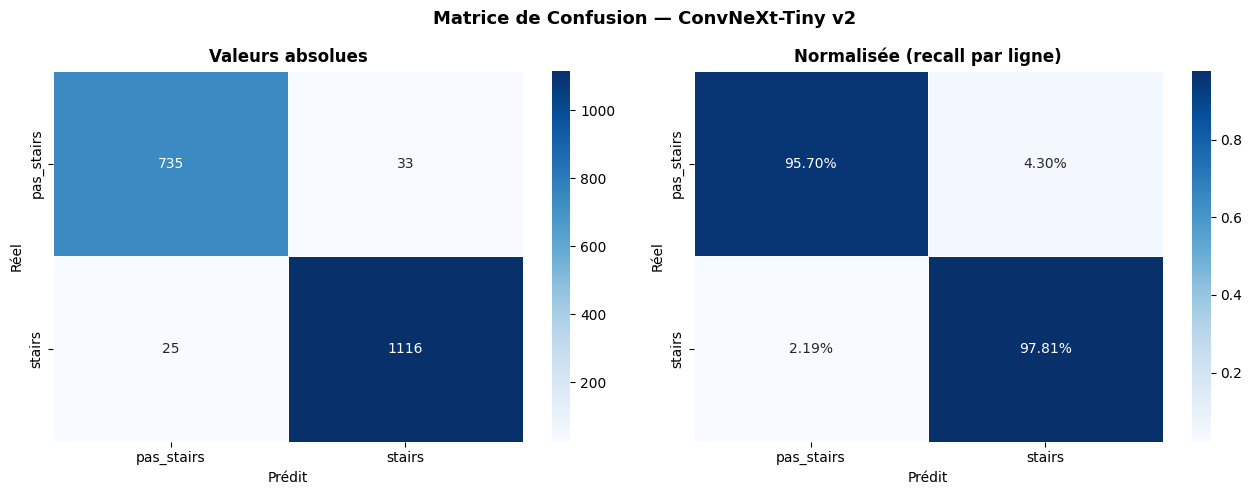

In [9]:
# ── Confusion Matrix ───────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Matrice de Confusion — ConvNeXt-Tiny v2", fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Valeurs absolues', 'Normalisée (recall par ligne)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

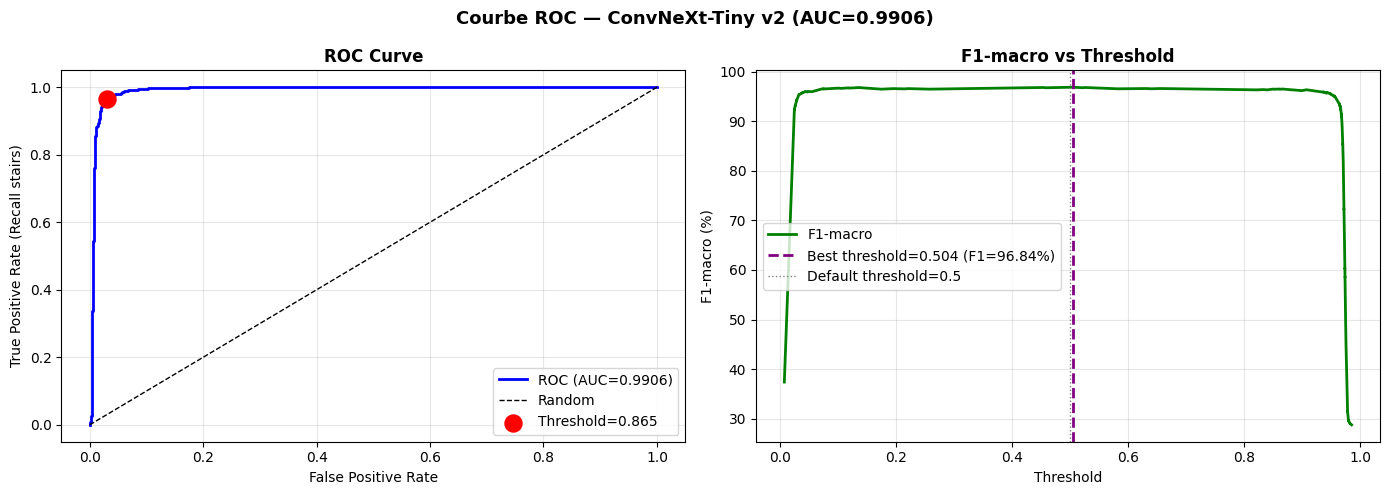

AUC              : 0.9906
Threshold optimal: 0.504  (F1=96.84%)
→ Utiliser threshold=0.504 dans l'intégration Object-Finder


In [10]:
# ── Courbe ROC + Threshold optimal ────────────────────────────
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc              = auc(fpr, tpr)

# Threshold optimal — maximise F1-macro
thresh_range = thresholds[thresholds <= 1.0]
f1s = []
for t in thresh_range:
    preds_t = (all_probs >= t).astype(int)
    f1s.append(f1_score(all_labels, preds_t, average='macro', zero_division=0))

best_t_idx  = np.argmax(f1s)
best_thresh = thresh_range[best_t_idx]
best_f1_t   = f1s[best_t_idx] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Courbe ROC — ConvNeXt-Tiny v2 (AUC={roc_auc:.4f})",
             fontsize=13, fontweight='bold')

# ── ROC ────────────────────────────────────────────────────────
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={roc_auc:.4f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random')
# Threshold optimal
opt_idx = np.argmin(np.sqrt(fpr**2 + (1-tpr)**2))
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], s=150, c='red', zorder=5,
                label=f'Threshold={thresholds[opt_idx]:.3f}')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall stairs)')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── F1 vs Threshold ────────────────────────────────────────────
axes[1].plot(thresh_range, [f*100 for f in f1s], 'g-', lw=2, label='F1-macro')
axes[1].axvline(x=best_thresh, color='purple', ls='--', lw=2,
                label=f'Best threshold={best_thresh:.3f} (F1={best_f1_t:.2f}%)')
axes[1].axvline(x=0.5, color='gray', ls=':', lw=1, label='Default threshold=0.5')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1-macro (%)')
axes[1].set_title('F1-macro vs Threshold', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC              : {roc_auc:.4f}")
print(f"Threshold optimal: {best_thresh:.3f}  (F1={best_f1_t:.2f}%)")
print(f"→ Utiliser threshold={best_thresh:.3f} dans l'intégration Object-Finder")

## 7 — Sauvegarde du Modèle Final

In [11]:
# ── Sauvegarde complète ────────────────────────────────────────
save_path = '/kaggle/working/convnext_stairs_v2_final.pth'
torch.save({
    'model_state_dict'  : best_model.state_dict(),
    'val_acc'           : val_acc_f,
    'val_f1'            : val_f1_f,
    'roc_auc'           : roc_auc,
    'optimal_threshold' : float(best_thresh),
    'class_names'       : CLASS_NAMES,
    'class_to_idx'      : CLASS_TO_IDX,
    'history'           : model_ft.history,
    'best_epoch'        : best_epoch,
    'version'           : 'v2_final — Loss seule + OneCycleLR'
}, save_path)

print(f" Modèle sauvegardé : {save_path}")
print(f"   Val Accuracy      : {val_acc_f:.2f}%")
print(f"   Val F1-macro      : {val_f1_f:.2f}%")
print(f"   AUC               : {roc_auc:.4f}")
print(f"   Threshold optimal : {best_thresh:.3f}")

 Modèle sauvegardé : /kaggle/working/convnext_stairs_v2_final.pth
   Val Accuracy      : 96.96%
   Val F1-macro      : 96.84%
   AUC               : 0.9906
   Threshold optimal : 0.504


## 8 — Intégration Object-Finder

In [12]:
# ── Fonction d'inférence — prête pour l'intégration YOLO ──────
def predict_stairs(image_path: str,
                   model,
                   threshold: float = best_thresh,
                   device   = device) -> dict:
    """
    Classifie un crop d'image en stairs / pas_stairs.

    Args:
        image_path : chemin vers le crop YOLO (224x224 recommandé)
        model      : ConvNeXtFineTunedV2 chargé
        threshold  : seuil de décision (optimal depuis courbe ROC)
        device     : cuda ou cpu

    Returns:
        dict : {
            'label'      : 'stairs' ou 'pas_stairs',
            'confidence' : probabilité (0-1),
            'danger'     : True si stairs détecté,
            'alert'      : message vocal
        }
    """
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225])
    ])

    image  = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        prob   = torch.softmax(logits, dim=1)[0, 1].item()

    label  = "stairs" if prob >= threshold else "pas_stairs"
    danger = label == "stairs"

    return {
        'label'     : label,
        'confidence': prob,
        'danger'    : danger,
        'alert'     : " Attention — escaliers détectés !" if danger else " Chemin dégagé"
    }

print("✅ Fonction predict_stairs prête")
print(f"   Threshold utilisé : {best_thresh:.3f} (optimal ROC)")
print()
print("Exemple d'utilisation dans le pipeline YOLO :")
print("""
  for box in yolo_results.boxes:
      crop = image.crop(box.xyxy)
      crop.save('/tmp/crop.jpg')
      result = predict_stairs('/tmp/crop.jpg', best_model)
      if result['danger']:
          print(result['alert'])
""")

✅ Fonction predict_stairs prête
   Threshold utilisé : 0.504 (optimal ROC)

Exemple d'utilisation dans le pipeline YOLO :

  for box in yolo_results.boxes:
      crop = image.crop(box.xyxy)
      crop.save('/tmp/crop.jpg')
      result = predict_stairs('/tmp/crop.jpg', best_model)
      if result['danger']:
          print(result['alert'])



## 9 — Résumé Final

### Pipeline complet — Rôle 2 Stairs

| Notebook | Rôle | Statut |
|---|---|---|
| `1-eda-preprocessing-stairs.ipynb` | EDA + extraction crops + train/val split | ✅ |
| `3_v1_Stairs_Draft.ipynb` | Brouillon — comparaison 4 modèles + double correction | ✅ |
| `3_v2_Stairs_Final.ipynb` | **Notebook final — Loss seule + OneCycleLR** | ✅ |

### Résultats comparaison (10 epochs, backbone gelé)

| Modèle | Val Acc | Stratégie |
|---|---|---|
| CNN Simple | 71.82% | From Scratch |
| MobileNetV2 | 85.91% | Transfer Learning |
| ResNet18 | 79.52% | Transfer Learning |
| **ConvNeXt-Tiny** | **92.61%** | **Transfer Learning ✅** |

### Résultats fine-tuning

| Version | Correction | Scheduler | Val F1 |
|---|---|---|---|
| v1 (brouillon) | Sampler + Loss | CosineAnnealingLR | 0.965 |
| **v2 (final)** | **Loss seule** | **OneCycleLR** | **voir résultats** |

### Intégration Object-Finder
```
YOLOv8 → crop 224×224 → ConvNeXt-Tiny v2 → stairs/pas_stairs
                                          → threshold optimal ROC
                                          → alerte vocale malvoyant
```

### Concepts clés démontrés (énoncé prof)
-  Transfer Learning + Fine-tuning dual lr
-  Comparaison 4 architectures
-  Gestion déséquilibre (v1 double, v2 simple)
-  Courbes d'apprentissage + LR schedule
-  Confusion matrix + Classification report
-  Courbe ROC + AUC + threshold optimal
-  Early Stopping + Model Checkpoint
-  Fonction d'inférence prête pour intégration